In [21]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

from lowRank import NMLRSSE
from lowRank import compute_expectation as ce
from utils import multi_index

In [22]:
# bath correlation function in Cai_2020_CPAM
Delta = 1
beta = 5/Delta
wc = 2.5 * Delta
wmax = 4 * wc
CapL = 200
factor = 1 - np.exp(-wmax/wc)
wl = -wc * np.log(1 - np.linspace(1, CapL, CapL)/CapL * factor)
cl = wl * np.sqrt((0.2 * wc/CapL) * factor)

_coth = 1.0 / np.tanh(0.5 * beta * wl)
_pref = (cl**2) / (2.0 * wl)
def bath_corr(t):
    t_arr = np.asarray(t)
    t1 = np.atleast_1d(t_arr).astype(float)
    phase = wl[:, None] * t1[None, :]             # shape: (CapL, len(t))
    out = np.sum(_pref[:, None] * (np.cos(phase) * _coth[:, None] - 1j * np.sin(phase)), axis=0)
    return out[0] if t_arr.ndim == 0 else out

In [23]:
# parameters for the simulation
tmax = 5.0 / Delta
N_steps = 200
psi0 = np.array([1.0, 0.0], dtype=complex)
N_traj = 10000
rank = 5
# hierarchy truncation (total order cutoff for the multi-index set)
# set smaller than N_steps to avoid combinatorial blow-up when rank grows
max_order = 10

# spin-boson model parameters
eps = [0, Delta, 2*Delta]
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
Hs = [Delta*sx + e*sz for e in eps]
L = sz

MultiIndex layers: 100%|██████████| 11/11 [00:00<00:00, 673.77it/s]


Low-rank decomposition computed in 0.59 seconds.


Trajectories: 100%|██████████| 10000/10000 [01:16<00:00, 131.17it/s]


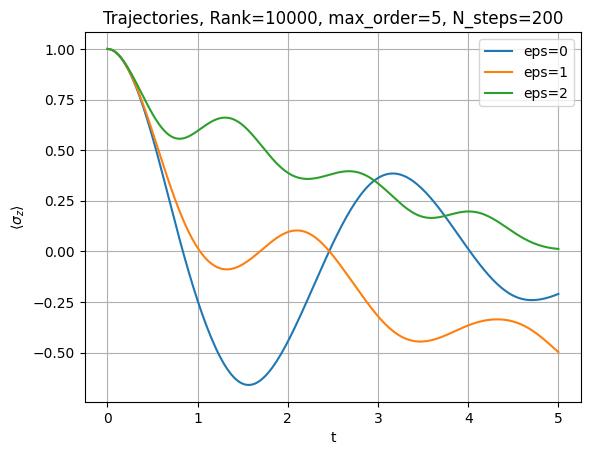

In [ ]:
parallel_traj = True

NMLRSSE_solver = NMLRSSE.NMLRSSE(
    Hs = Hs[0],
    L = L,
    bath_corr = bath_corr,
    tmax = tmax,
    N_steps = N_steps,
    rank = rank,
    max_order = max_order,
 )
psis = NMLRSSE_solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
sigma_z = ce.compute_expectation_value(psis, sz)
plt.plot(NMLRSSE_solver.t_grid, sigma_z, label='eps={}'.format(eps[0]))

NMLRSSE_solver.set_Hamiltonian(Hs[1])
psis = NMLRSSE_solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
sigma_z = ce.compute_expectation_value(psis, sz)
plt.plot(NMLRSSE_solver.t_grid, sigma_z, label='eps={}'.format(eps[1]))

NMLRSSE_solver.set_Hamiltonian(Hs[2])
psis = NMLRSSE_solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
sigma_z = ce.compute_expectation_value(psis, sz)
plt.plot(NMLRSSE_solver.t_grid, sigma_z, label='eps={}'.format(eps[2]))

plt.xlabel('t')
plt.ylabel(r'$\langle \sigma_z \rangle$')
plt.title('{} Trajectories, Rank={}, max_order={}, N_steps={}'.format(N_traj, rank, max_order, N_steps))
plt.grid()
plt.legend()
plt.show()